In [336]:
import numpy as np

def make_web(n,k,kmin=0):
    #den her funktion laver et helt random netværk af n sider, hvor hver side har mellem kmin og k links til andre sider.
    

    # Input: n og k er ikke-negative heltal
    # Output: web er en dictionary med n nøgler.
    # Værdien af hver nøgle er en mængde, der er en delmængde af nøglerne.
    
    assert(k < n), "k skal være mindre end n (da man ikke kan linke til sig selv)"
    assert(kmin <= k), "kmin skal være mindre end eller lig med k"
    keys = [i for i in range(n)]# laver en liste fra [0, 1, 2, ..., n-1]
    web = dict()
    for j in keys:
        #for hver hjemmeside finder vi hvor mange hjemmesider den skal linke til (numlinks) og derefter vælger vi hvilke hjemmesider den skal linke til (web[j])
        numlinks = np.random.randint(kmin,k) # generér et tilfældigt tal mellem kmin og k
        web[j] = set() # starter med en tom mængde for hver hjemmeside
        links = []
        for _ in range(numlinks): # nu vælger vi numlinks tilfældige hjemmesider at linke til
            link = np.random.choice(keys) # vælg en tilfældig hjemmeside fra keys
            if link != j: # sørg for at hjemmesiden ikke linker til sig selv
                links.append(int(link)) # tilføj den valgte hjemmeside til links-listen
        web[j] = set(links) # konverter links-listen til en mængde og tildel den til web[j]
    return web

In [337]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_graph(web):
    
    # Input: netværk som dictionary
    # Output: Netværk visualiseret som graf

    G = nx.DiGraph()
    for node, links in web.items():
        G.add_node(node)
        for link in links:
            G.add_edge(node, link)

    pos = nx.spring_layout(G)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', font_size=8, arrows=True)

    # INDSÆT KODE HER

    plt.show()

In [ ]:
#opgave 9
def surf_step(web, startpage):
    
    # Input: Et netværk som dictionary og en start side
    # Output: Sandsynlighedsfordeling som dictionary for næste hjemmeside
    
    distribution=dict() # laver en tom dictionary til at gemme sandsynlighedsfordelingen

    for page, links in web.items(): # for hver hjemmeside og dens links i web-dictionaryen
        if links == set(): # hvis hjemmesiden ikke har nogen links, så skal den have en ligelig fordeling over alle sider
            distribution[page] = [1/len(web) for i in range(len(web))] # fordel sandsynligheden ligeligt over alle sider fx laver den [0, 0, 0, 0, 0] -> [1/5, 1/5, 1/5, 1/5, 1/5]
        else: # hvis hjemmesiden har links, så skal den fordele sandsynligheden ligeligt over de sider den linker til
            distribution[page] = [0 for i in range(len(web))] # starter med at lave [0, 0, 0, 0, 0] for hver hjemmeside
            for link in links:
                distribution[page][link] += 1/len(links) # her taget den fx [0, 1, 0, 1, 0] og laver den til [0, 1/2, 0, 1/2, 0] hvis der er 2 links

    
    return distribution#[startpage] # returner sandsynlighedsfordelingen for den startside vi har valgt

In [339]:
#opgave 10
def random_surf(web, n):

    # Input: Et netværk som dictionary og antallet af skridt i random surf simuleringen
    # Output: PageRank-værdier for hver side som en dictionary
    ranking=dict()
    starts = [i for i in web.keys()] # en liste over alle hjemmesider
    start_page = np.random.choice(starts) # vælg en random hjemmeside at starte på
    for i in range(n):
        distribution = surf_step(web, start_page) # start med at find sandsynlighedsfordelingen for den startside vi har valgt
        distribution = distribution[start_page]
        indices = np.arange(len(distribution))
        start_page = np.random.choice(indices, p=distribution) # vælg en ny startside baseret på sandsynlighedsfordelingen
        if start_page not in ranking.keys(): # hver gang vi lander på en hjemmeside, så tæller vi det i ranking-dictionaryen
            ranking[int(start_page)] = 1
        else:
            ranking[int(start_page)] +=1
    for i in ranking.keys():
        ranking[i] = ranking[i]/n # til sidst dividerer vi hver tælling i ranking-dictionaryen med n for at få en sandsynlighedsfordeling over hvor ofte vi lander på hver hjemmeside
    
    # INDSÆT KODE HER

    return ranking

In [340]:
web = make_web(10, 6)

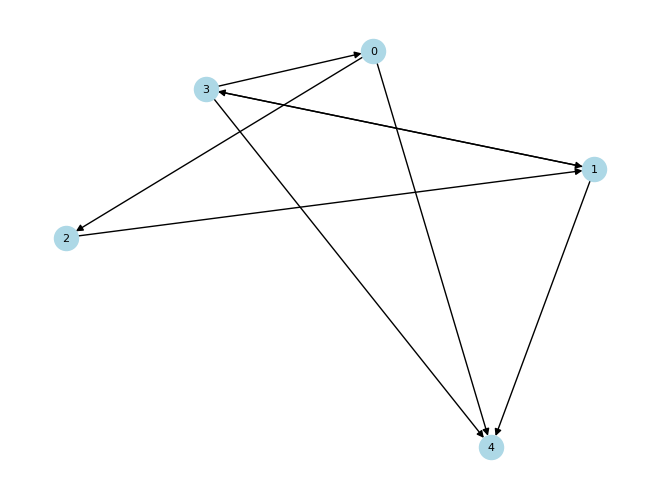

In [341]:
visualize_graph(W1)

# opgave 11

In [342]:
def surf_step_damp(web, start_page, d):
    
    # Input: Et netværk som dictionary, en start side og en dæmpningsfaktor
    # Output: Sandsynlighedsfordeling som dictionary for næste hjemmeside
    
    distribution=dict()

    distribution=dict() # laver en tom dictionary til at gemme sandsynlighedsfordelingen

    for page, links in web.items(): # for hver hjemmeside og dens links i web-dictionaryen
        if links == set(): # hvis hjemmesiden ikke har nogen links, så skal den have en ligelig fordeling over alle sider
            distribution[page] = [1/len(web) for i in range(len(web))] # fordel sandsynligheden ligeligt over alle sider fx laver den [0, 0, 0, 0, 0] -> [1/5, 1/5, 1/5, 1/5, 1/5]
        else: # hvis hjemmesiden har links, så skal den fordele sandsynligheden ligeligt over de sider den linker til
            distribution[page] = [0 for i in range(len(web))] # starter med at lave [0, 0, 0, 0, 0] for hver hjemmeside
            for link in links:
                distribution[page][link] += 1/len(links) # her taget den fx [0, 1, 0, 1, 0] og laver den til [0, 1/2, 0, 1/2, 0] hvis der er 2 links


    # INDSÆT KODE HER

    uniform = [1/len(web) for i in range(len(web))]
    sandsynlighed = [d, 1-d]
    indices = [1, 2]
    number = np.random.choice(indices, p=sandsynlighed)
    if number == 1:
        test = distribution[start_page]
    if number == 2:
        test = uniform
    return test

In [344]:
def random_surf_damp(web, n, d):

    # Input: Et netværk som dictionary, antallet af skridt i random surf simuleringen og en dæmpningsfaktor
    # Output: PageRank-værdier for hver side som en dictionary

        # Input: Et netværk som dictionary og antallet af skridt i random surf simuleringen
    # Output: PageRank-værdier for hver side som en dictionary
    ranking=dict()
    starts = [i for i in web.keys()] # en liste over alle hjemmesider
    start_page = np.random.choice(starts) # vælg en random hjemmeside at starte på
    for i in range(n):
        distribution = surf_step_damp(web, start_page, 0.85) # start med at find sandsynlighedsfordelingen for den startside vi har valgt
        indices = np.arange(len(distribution))
        start_page = np.random.choice(indices, p=distribution) # vælg en ny startside baseret på sandsynlighedsfordelingen
        if start_page not in ranking.keys(): # hver gang vi lander på en hjemmeside, så tæller vi det i ranking-dictionaryen
            ranking[int(start_page)] = 1
        else:
            ranking[int(start_page)] +=1
    for i in ranking.keys():
        ranking[i] = ranking[i]/n # til sidst dividerer vi hver tælling i ranking-dictionaryen med n for at få en sandsynlighedsfordeling over hvor ofte vi lander på hver hjemmeside
    



 
    # INDSÆT KODE HER

    return ranking

In [345]:
W2 = {
    0: {1},
    1: {2},
    2: {0},
    3: {4},
    4: {5},
    5: {3}}


W1 = {
    0: {2, 4},
    1: {3, 4},
    2: {1},
    3: {0, 1, 4},
    4: set()}

# opgave 13

In [346]:
for n in range(1000, 1010, 1):
    print(random_surf(W1, n))

{4: 0.307, 0: 0.135, 2: 0.13, 1: 0.233, 3: 0.195}
{1: 0.25274725274725274, 4: 0.3086913086913087, 2: 0.11888111888111888, 3: 0.18681318681318682, 0: 0.13286713286713286}
{3: 0.18862275449101795, 0: 0.12674650698602793, 4: 0.29840319361277445, 2: 0.13373253493013973, 1: 0.25249500998003993}
{3: 0.18943170488534397, 0: 0.12163509471585245, 4: 0.3160518444666002, 1: 0.24227318045862412, 2: 0.13060817547357925}
{3: 0.18127490039840638, 0: 0.12250996015936255, 4: 0.3286852589641434, 2: 0.12749003984063745, 1: 0.2400398406374502}
{4: 0.32238805970149254, 3: 0.19601990049751244, 0: 0.13233830845771144, 2: 0.11044776119402985, 1: 0.23880597014925373}
{2: 0.14314115308151093, 1: 0.2504970178926441, 3: 0.1679920477137177, 4: 0.31510934393638174, 0: 0.12326043737574553}
{3: 0.17874875868917578, 0: 0.12313803376365443, 2: 0.1300893743793446, 1: 0.2502482621648461, 4: 0.31777557100297915}
{4: 0.31646825396825395, 1: 0.24801587301587302, 3: 0.18948412698412698, 0: 0.11805555555555555, 2: 0.127976190

In [347]:
for n in range(1000, 1010, 1):
    print(random_surf(W2, n))

{5: 0.334, 3: 0.333, 4: 0.333}
{3: 0.3336663336663337, 4: 0.3336663336663337, 5: 0.33266733266733267}
{0: 0.3333333333333333, 1: 0.3333333333333333, 2: 0.3333333333333333}
{3: 0.3339980059820538, 4: 0.33300099700897307, 5: 0.33300099700897307}
{3: 0.3336653386454183, 4: 0.3336653386454183, 5: 0.33266932270916333}
{2: 0.3333333333333333, 0: 0.3333333333333333, 1: 0.3333333333333333}
{4: 0.33399602385685884, 5: 0.33300198807157055, 3: 0.33300198807157055}
{5: 0.3336643495531281, 3: 0.3336643495531281, 4: 0.3326713008937438}
{2: 0.3333333333333333, 0: 0.3333333333333333, 1: 0.3333333333333333}
{1: 0.333994053518335, 2: 0.3330029732408325, 0: 0.3330029732408325}


In [348]:
for n in range(1000, 1010, 1):
    print(random_surf_damp(W1, n, 0.85))

{4: 0.276, 3: 0.192, 1: 0.249, 2: 0.142, 0: 0.141}
{2: 0.12787212787212787, 1: 0.24275724275724275, 3: 0.1878121878121878, 0: 0.13186813186813187, 4: 0.3096903096903097}
{2: 0.13373253493013973, 1: 0.249500998003992, 3: 0.1936127744510978, 4: 0.2844311377245509, 0: 0.13872255489021956}
{1: 0.2382851445663011, 3: 0.18843469591226322, 0: 0.12861415752741776, 4: 0.3160518444666002, 2: 0.12861415752741776}
{0: 0.13147410358565736, 4: 0.29282868525896416, 1: 0.24302788844621515, 3: 0.1902390438247012, 2: 0.14243027888446216}
{1: 0.24776119402985075, 4: 0.3054726368159204, 0: 0.13034825870646766, 3: 0.1791044776119403, 2: 0.1373134328358209}
{4: 0.2813121272365805, 0: 0.13916500994035785, 2: 0.14612326043737575, 1: 0.24950298210735586, 3: 0.18389662027833}
{4: 0.27507447864945384, 3: 0.2035749751737835, 1: 0.24826216484607747, 0: 0.14597815292949354, 2: 0.12711022840119166}
{4: 0.2847222222222222, 2: 0.14285714285714285, 1: 0.24206349206349206, 3: 0.1865079365079365, 0: 0.14384920634920634}


In [349]:
for n in range(1000, 1010, 1):
    print(random_surf_damp(W2, n, 0.85))

{4: 0.154, 5: 0.151, 3: 0.155, 1: 0.179, 2: 0.178, 0: 0.183}
{3: 0.1968031968031968, 4: 0.19480519480519481, 5: 0.1928071928071928, 1: 0.13186813186813187, 2: 0.14285714285714285, 0: 0.14085914085914086}
{4: 0.16666666666666666, 5: 0.16467065868263472, 3: 0.16067864271457086, 0: 0.17564870259481039, 1: 0.16766467065868262, 2: 0.16467065868263472}
{0: 0.16450648055832504, 1: 0.16849451645064806, 2: 0.16849451645064806, 5: 0.1694915254237288, 3: 0.16051844466600199, 4: 0.16849451645064806}
{3: 0.17729083665338646, 4: 0.18127490039840638, 5: 0.18127490039840638, 1: 0.15836653386454183, 2: 0.14940239043824702, 0: 0.15239043824701196}
{2: 0.1691542288557214, 0: 0.16517412935323383, 1: 0.16517412935323383, 4: 0.16318407960199005, 5: 0.17114427860696518, 3: 0.16616915422885573}
{4: 0.15805168986083498, 5: 0.15308151093439365, 3: 0.15606361829025844, 0: 0.18389662027833, 1: 0.17296222664015903, 2: 0.17594433399602386}
{2: 0.18669314796425024, 0: 0.18768619662363456, 1: 0.1926514399205561, 3: 0

# opgave 15

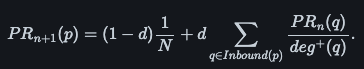

In [259]:
#en ad gangen
def rank_update(web, PageRanks, page, d):
        N = len(web)
        """
        Opdaterer værdien af PageRank for en side baseret på den rekursive formel
        Sider uden udgående links (sinks) behandles som om de linker til alle sider på nettet.

        Input: 
            web og PageRanks er dictionaries som i outputtet fra "make_web" og "random_surf",
            page er nøglen til den side, hvis rank vi ønsker at opdatere, og
            d er dampingfaktoren.
        Output: 
            PageRank opdateres i henhold til ovenstående formel,
            og denne funktion returnerer et float "increment", den (absolutte) forskel
            mellem den tidligere værdi og den opdaterede værdi af PR(p).
        """
        inbound_sum = 0
        for q, p in web.items():
            #print(q, p)
            if page in p:
                inbound_sum += PageRanks[q]/len(p)
            if p == set():
                 inbound_sum += PageRanks[q]/(len(web))
        
        new_rank = (1-d)*(1/N) + (d*(inbound_sum))
        change = abs(PageRanks[page] - new_rank)
        #PageRanks[page] = new_rank
        return change

In [260]:
#en ad gangen
def recursive_PageRank(web, stopvalue=0.0001, max_iterations=200, d=0.85):
    """
    Implementerer den rekursive version af PageRank-algoritmen ved først at oprette
    en PageRank på 1/N til alle sider (hvor N er det samlede antal sider)
    og derefter anvende "rank_update" gentagne gange, indtil en af de to stopbetingelser
    er opnået:
    stopbetingelse 1: den maksimale ændring fra trin n til trin (n+1) over alle PageRank
    er mindre end stopværdien,
    Stopbetingelse 2: antallet af iterationer har nået "max_iterations".

    Input: web er et dictionary som i outputtet af "make_web", d er dæmpningen,
    stopvalue er et positivt float, max_iterations er et positivt heltal.
    """
    PageRanks = dict()
    for i in range(len(web)):
        PageRanks[i] = 1/len(web)
    latest_increment = dict()
    for iteration in range(max_iterations):
        stop = 0 
        for page in web.keys():
            change = rank_update(web, PageRanks, page, d)
            #print(change)
            if change < stopvalue:
                stop += 1
                #print(stop)
        if stop == len(web.keys()):
            return PageRanks, iteration


    return PageRanks, iteration

In [261]:
#Man kan enten Gauss-Seidel metoden hvor man enkeltvis opdaterer hver pagerank
#Ellers kan man bruge Jacobi, hvor man opdaterer alle på en gang.
def rank_update(web, PageRanks, page, d):
        N = len(web)
        """
        Opdaterer værdien af PageRank for en side baseret på den rekursive formel
        Sider uden udgående links (sinks) behandles som om de linker til alle sider på nettet.

        Input: 
            web og PageRanks er dictionaries som i outputtet fra "make_web" og "random_surf",
            page er nøglen til den side, hvis rank vi ønsker at opdatere, og
            d er dampingfaktoren.
        Output: 
            PageRank opdateres i henhold til ovenstående formel,
            og denne funktion returnerer et float "increment", den (absolutte) forskel
            mellem den tidligere værdi og den opdaterede værdi af PR(p).
        """
        inbound_sum = 0
        for q, p in web.items():
            #print(q, p)
            if page in p:
                inbound_sum += PageRanks[q]/len(p)
            if p == set():
                 inbound_sum += PageRanks[q]/(len(web))
        
        new_rank = (1-d)*(1/N) + (d*(inbound_sum))
        change = abs(PageRanks[page] - new_rank)
        #PageRanks[page] = new_rank
        return new_rank

In [352]:

def recursive_PageRank(web, stopvalue=0.0001, max_iterations=200, d=0.85):
    """
    Implementerer den rekursive version af PageRank-algoritmen ved først at oprette
    en PageRank på 1/N til alle sider (hvor N er det samlede antal sider)
    og derefter anvende "rank_update" gentagne gange, indtil en af de to stopbetingelser
    er opnået:
    stopbetingelse 1: den maksimale ændring fra trin n til trin (n+1) over alle PageRank
    er mindre end stopværdien,
    Stopbetingelse 2: antallet af iterationer har nået "max_iterations".

    Input: web er et dictionary som i outputtet af "make_web", d er dæmpningen,
    stopvalue er et positivt float, max_iterations er et positivt heltal.
    """
    PageRanks = dict()
    for i in range(len(web)):
        PageRanks[i] = 1/len(web)
    for iteration in range(max_iterations):
        new_rank = {}
        for page in web.keys():
            new_rank[page] = rank_update(web, PageRanks, page, d)
            #print(max(list(change.items()))[1])
        max_change = max(abs(new_rank[p] - PageRanks[p]) for p in web.keys())
        PageRanks = new_rank
        if max_change < stopvalue:
            return PageRanks, iteration


    return PageRanks, iteration

In [353]:
recursive_PageRank(W1)

({0: 0.1329244916791924,
  1: 0.24910563421313253,
  2: 0.1366725097485432,
  3: 0.18604928854533567,
  4: 0.29524807581379636},
 10)

# opgave 16/17

In [355]:
surf_step(W1, 0)

{0: [0, 0, 0.5, 0, 0.5],
 1: [0, 0, 0, 0.5, 0.5],
 2: [0, 1.0, 0, 0, 0],
 3: [0.3333333333333333, 0.3333333333333333, 0, 0, 0.3333333333333333],
 4: [0.2, 0.2, 0.2, 0.2, 0.2]}

In [383]:

def modified_link_matrix(web, pagelist=None, d=0.85):

    # Input: web (dictionary), pagelist (liste over nøgler), d (dæmpningsfaktor)
    # Output: d*A^T + (1-d)*E/N
    
    N=len(web)
    E_N = np.ones((N, N))
    distri = surf_step(W1, 0)
    L = np.array([i for i in distri.values()])

    # A: NxN numpy array, hvor række j har ikke-nul elementer i søjler, som side j linker til.
    # Hvis side j ikke linker til nogen, får alle elementer i række j værdien 1/N.
    # E: np.ones([N,N])

    M_d = (((1-d)/N) * E_N) + d*(L.T)
    return M_d

    

In [384]:
M = modified_link_matrix(W1)
eigenvalues, eigenvects = np.linalg.eig(M)

In [ ]:
# v er egenvektoren der har en egenværdi på 1. man kan se at v har præcis de samme værdier som man får når  man kører recursive_pagerank algoritmen
v = eigenvects[:,0]/np.sum(eigenvects[:,0])
v

array([0.13291062+0.j, 0.24908977+0.j, 0.13668135+0.j, 0.18605748+0.j,
       0.29526078+0.j])

# opgave 18

In [ ]:
#hvis man summer alle søjlerne har de en værdi på 1
np.sum(M,axis=0)

array([1., 1., 1., 1., 1.])